In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

In [2]:
#load clean data
processed_dir = Path.home() / "Documents" / "diabetes-risk-project" / "data" / "processed"

df = pd.read_csv(processed_dir / "clean_project_dataset.csv")

print(df.shape)
df.head()

(9232, 37)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPXOSY1,BPXOSY2,...,ALQ111,ALQ121,ALQ130,DBQ700,DBD895,DBD900,DBD905,DBD910,doctor_diabetes,diabetes
0,109266.0,29.0,2.0,6.0,5.0,5.00,37.8,117.9,99.0,99.0,...,1.0,1.000000e+01,1.0,3.0,7.000000e+00,5.397605e-79,5.397605e-79,5.000000e+00,0.0,0
1,109267.0,21.0,2.0,2.0,4.0,5.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,4.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,0.0,0
2,109271.0,49.0,1.0,3.0,2.0,NaN,29.7,120.4,102.0,108.0,...,1.0,5.397605e-79,NaN,3.0,2.000000e+00,2.000000e+00,5.397605e-79,5.397605e-79,0.0,0
3,109273.0,36.0,1.0,3.0,4.0,0.83,21.9,86.8,116.0,110.0,...,1.0,5.397605e-79,NaN,4.0,2.000000e+00,2.000000e+00,5.397605e-79,7.000000e+00,0.0,0
4,109274.0,68.0,1.0,7.0,4.0,1.20,30.2,109.6,138.0,132.0,...,1.0,4.000000e+00,2.0,2.0,5.397605e-79,NaN,5.397605e-79,5.397605e-79,1.0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9232 entries, 0 to 9231
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEQN             9232 non-null   float64
 1   RIDAGEYR         9232 non-null   float64
 2   RIAGENDR         9232 non-null   float64
 3   RIDRETH3         9232 non-null   float64
 4   DMDEDUC2         9217 non-null   float64
 5   INDFMPIR         7828 non-null   float64
 6   BMXBMI           8381 non-null   float64
 7   BMXWAIST         8055 non-null   float64
 8   BPXOSY1          7648 non-null   float64
 9   BPXOSY2          7637 non-null   float64
 10  BPXOSY3          7619 non-null   float64
 11  BPXODI1          7648 non-null   float64
 12  BPXODI2          7637 non-null   float64
 13  BPXODI3          7619 non-null   float64
 14  DIQ010           9227 non-null   float64
 15  LBXGH            8081 non-null   float64
 16  LBXGLU           4004 non-null   float64
 17  BPQ020        

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SEQN,9232.0,117061.091746,4488.309008,1.092660e+05,1.131812e+05,1.170215e+05,120945.2500,124822.0
RIDAGEYR,9232.0,51.144931,17.686659,2.000000e+01,3.600000e+01,5.200000e+01,65.0000,80.0
RIAGENDR,9232.0,1.514840,0.499807,1.000000e+00,1.000000e+00,2.000000e+00,2.0000,2.0
RIDRETH3,9232.0,3.489710,1.561820,1.000000e+00,3.000000e+00,3.000000e+00,4.0000,7.0
DMDEDUC2,9217.0,3.543561,1.196637,1.000000e+00,3.000000e+00,4.000000e+00,4.0000,5.0
INDFMPIR,7828.0,2.597786,1.626501,5.397605e-79,1.190000e+00,2.210000e+00,4.2025,5.0
BMXBMI,8381.0,30.039017,7.565943,1.420000e+01,2.490000e+01,2.880000e+01,33.8000,92.3
BMXWAIST,8055.0,100.987039,17.130987,5.790000e+01,8.900000e+01,9.950000e+01,111.5000,187.5
BPXOSY1,7648.0,125.075052,19.947541,6.600000e+01,1.110000e+02,1.220000e+02,136.0000,225.0
BPXOSY2,7637.0,124.791672,19.746599,6.900000e+01,1.110000e+02,1.220000e+02,136.0000,222.0


In [5]:
df["diabetes"].value_counts()

diabetes
0    7412
1    1820
Name: count, dtype: int64

In [6]:
df["diabetes"].value_counts(normalize=True)

diabetes
0    0.80286
1    0.19714
Name: proportion, dtype: float64

### Leakage Check

A leakage check was performed before modeling. Variables that directly encoded the diabetes outcome or were used to construct the target were excluded from the predictor set.

The variables `doctor_diabetes`, `DIQ010`, `LBXGH`, and `LBXGLU` were removed because they directly reflect diabetes diagnosis or clinical criteria used to define the target. The target variable `diabetes` itself was also removed from the feature set. This prevents the model from learning the answer directly rather than learning from general risk factors.

In [7]:
# Columns that should not be used as predictors

drop_cols = ["SEQN", "diabetes", "doctor_diabetes", "DIQ010", "LBXGH", "LBXGLU"]

target_col = "diabetes"

feature_cols = [col for col in df.columns if col not in drop_cols]

print("Number of total columns:", df.shape[1])
print("Number of feature columns:", len(feature_cols))
print("Feature columns:")
feature_cols

Number of total columns: 37
Number of feature columns: 31
Feature columns:


['RIDAGEYR',
 'RIAGENDR',
 'RIDRETH3',
 'DMDEDUC2',
 'INDFMPIR',
 'BMXBMI',
 'BMXWAIST',
 'BPXOSY1',
 'BPXOSY2',
 'BPXOSY3',
 'BPXODI1',
 'BPXODI2',
 'BPXODI3',
 'BPQ020',
 'BPQ080',
 'SMQ020',
 'PAQ650',
 'PAQ655',
 'PAD660',
 'PAQ665',
 'PAQ670',
 'PAD675',
 'PAD680',
 'ALQ111',
 'ALQ121',
 'ALQ130',
 'DBQ700',
 'DBD895',
 'DBD900',
 'DBD905',
 'DBD910']

## Feature Selection: Domain Knowledge

Feature selection was first guided by domain knowledge rather than including every available variable. Variables were kept only if they had a plausible connection to diabetes risk, such as demographic characteristics, body measurements, blood pressure, physical activity, smoking, alcohol use, diet, and socioeconomic status.

Several variables were excluded before modeling. `SEQN` was removed because it is only a
participant identifier and does not contain predictive health information. The target variable `diabetes` was removed from the feature set. Variables directly used to define the diabetes
outcome, including `doctor_diabetes`, `DIQ010`, `LBXGH`, and `LBXGLU`, were also removed 
to avoid data leakage.

This domain-knowledge filtering helps reduce the risk of overfitting and supports more 
interpretable modeling. It also helps address the curse of dimensionality by avoiding 
unnecessary or non-defensible predictors.

## 5. Missing Data Analysis


In [8]:
# Missing data summary for all columns
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
PAD660,7047,76.332322
PAQ655,7041,76.267331
PAD675,5535,59.954506
PAQ670,5526,59.857019
LBXGLU,5228,56.629116
ALQ130,3619,39.200607
DBD900,2031,21.999567
ALQ121,2001,21.674610
BPXODI3,1613,17.471837
BPXOSY3,1613,17.471837


In [9]:
# Missing data summary for predictor features only

missing_features = pd.DataFrame({
    "missing_count": df[feature_cols].isna().sum(),
    "missing_percent": df[feature_cols].isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_features

,missing_count,missing_percent
PAD660,7047,76.332322
PAQ655,7041,76.267331
PAD675,5535,59.954506
PAQ670,5526,59.857019
ALQ130,3619,39.200607
DBD900,2031,21.999567
ALQ121,2001,21.674610
BPXOSY3,1613,17.471837
BPXODI3,1613,17.471837
BPXOSY2,1595,17.276863


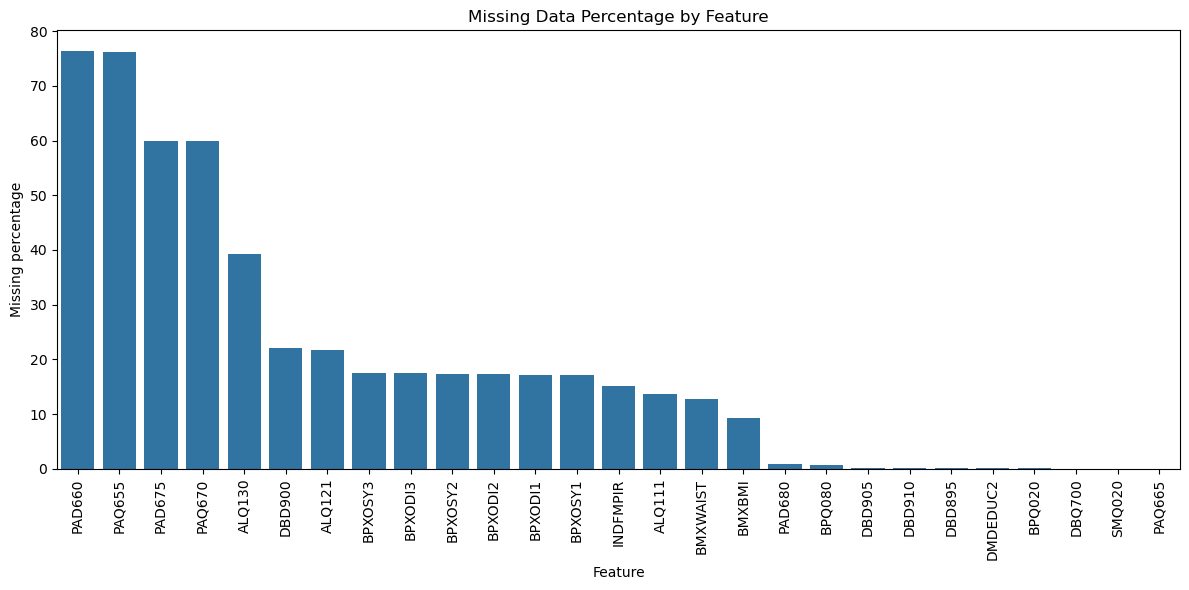

In [10]:
# Plot missingness for feature columns

missing_features_nonzero = missing_features[missing_features["missing_percent"] > 0]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=missing_features_nonzero.reset_index(),
    x="index",
    y="missing_percent"
)
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Missing percentage")
plt.title("Missing Data Percentage by Feature")
plt.tight_layout()
plt.show()

In [11]:
# Categorize features by missingness level

missing_features["missing_level"] = pd.cut(
    missing_features["missing_percent"],
    bins=[-0.1, 5, 20, 50, 100],
    labels=["low_missing", "moderate_missing", "high_missing", "very_high_missing"]
)

missing_features

,missing_count,missing_percent,missing_level
PAD660,7047,76.332322,very_high_missing
PAQ655,7041,76.267331,very_high_missing
PAD675,5535,59.954506,very_high_missing
PAQ670,5526,59.857019,very_high_missing
ALQ130,3619,39.200607,high_missing
DBD900,2031,21.999567,high_missing
ALQ121,2001,21.674610,high_missing
BPXOSY3,1613,17.471837,moderate_missing
BPXODI3,1613,17.471837,moderate_missing
BPXOSY2,1595,17.276863,moderate_missing


In [12]:
# Features with more than 50% missingness

high_missing_features = missing_features[missing_features["missing_percent"] > 50]

high_missing_features

,missing_count,missing_percent,missing_level
PAD660,7047,76.332322,very_high_missing
PAQ655,7041,76.267331,very_high_missing
PAD675,5535,59.954506,very_high_missing
PAQ670,5526,59.857019,very_high_missing


In [13]:
# Missingness by diabetes status

missing_by_target = df.groupby("diabetes")[feature_cols].apply(lambda x: x.isna().mean() * 100)

missing_by_target.T.sort_values(by=1, ascending=False)

diabetes,0,1
PAD660,73.030221,89.780220
PAQ655,72.962763,89.725275
PAD675,57.838640,68.571429
PAQ670,57.717215,68.571429
ALQ130,36.818672,48.901099
DBD900,20.992984,26.098901
ALQ121,21.748516,21.373626
BPXODI3,17.808958,16.098901
BPXOSY3,17.808958,16.098901
BPXOSY2,17.660550,15.714286


### Missing Data Findings
Several variables have high missingness, especially physical activity duration 
variables such as `PAD660`, `PAQ655`, `PAD675`, and `PAQ670`. Missingness is higher
among participants with diabetes for some of these variables. This suggests that 
missingness may not be completely random and should be handled carefully during 
modeling. For now, variables are kept for EDA, and later modeling pipelines should 
use imputation and possibly missing-value indicators rather than dropping many rows.

In [14]:
# Important numeric variables for distribution plots

numeric_features = [
    "RIDAGEYR",     # age
    "INDFMPIR",     # income-to-poverty ratio
    "BMXBMI",       # BMI
    "BMXWAIST",     # waist circumference
    "BPXOSY1", "BPXOSY2", "BPXOSY3",   # systolic BP
    "BPXODI1", "BPXODI2", "BPXODI3",   # diastolic BP
    "PAD680"        # sedentary minutes
]

numeric_features = [col for col in numeric_features if col in feature_cols]

numeric_features

['RIDAGEYR',
 'INDFMPIR',
 'BMXBMI',
 'BMXWAIST',
 'BPXOSY1',
 'BPXOSY2',
 'BPXOSY3',
 'BPXODI1',
 'BPXODI2',
 'BPXODI3',
 'PAD680']

In [15]:
figures_dir = Path.home() / "Documents" / "diabetes-risk-project" / "results" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


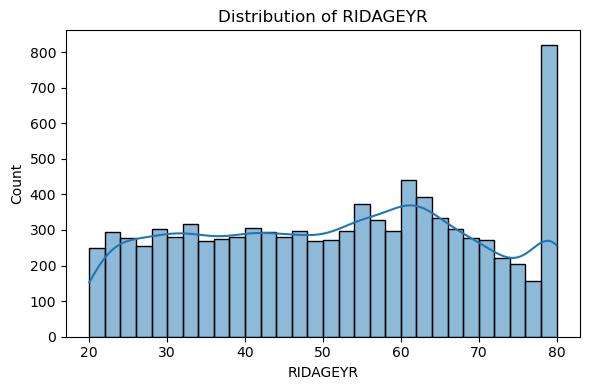

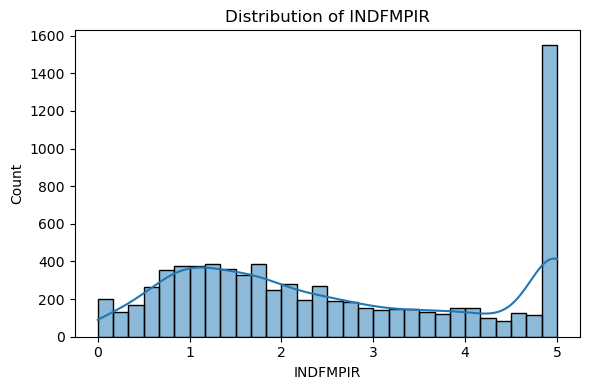

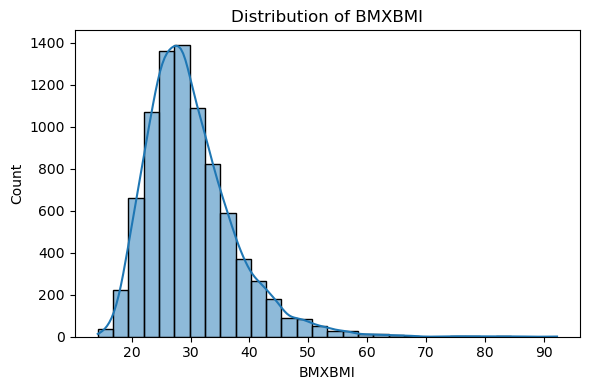

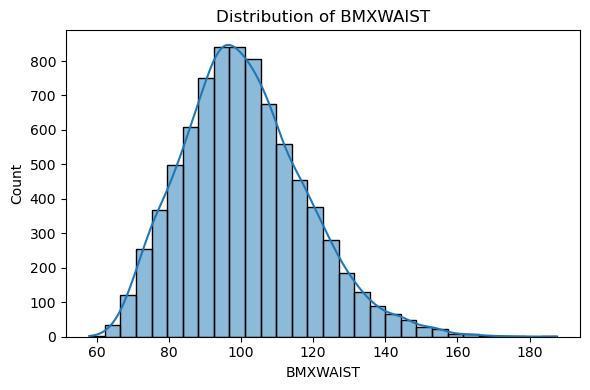

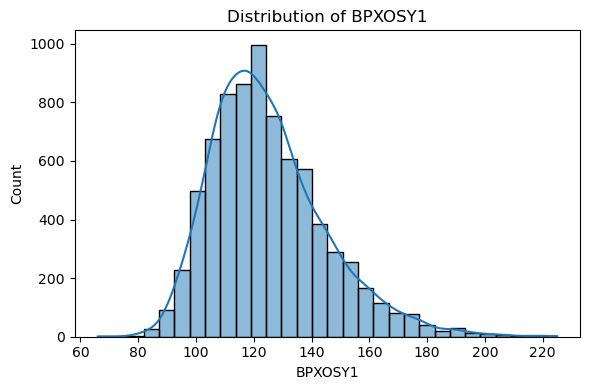

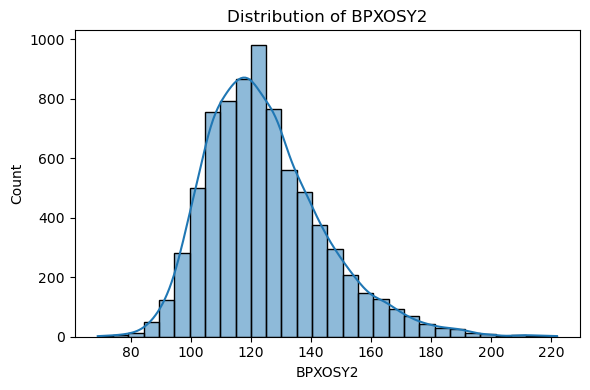

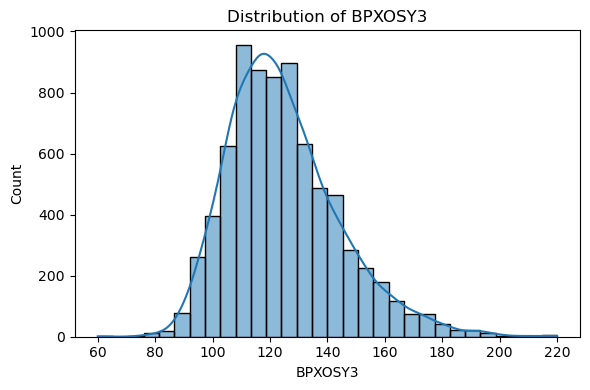

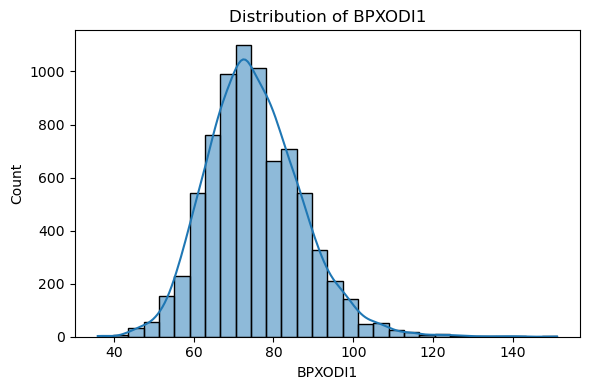

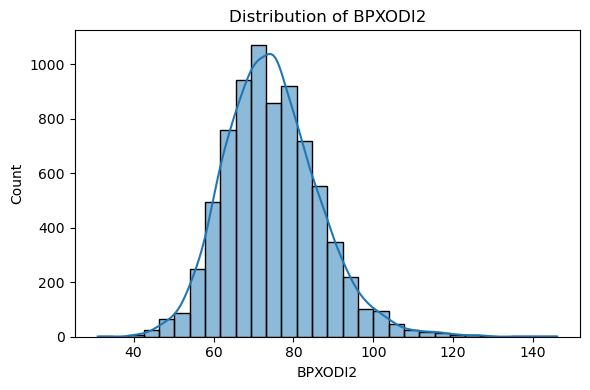

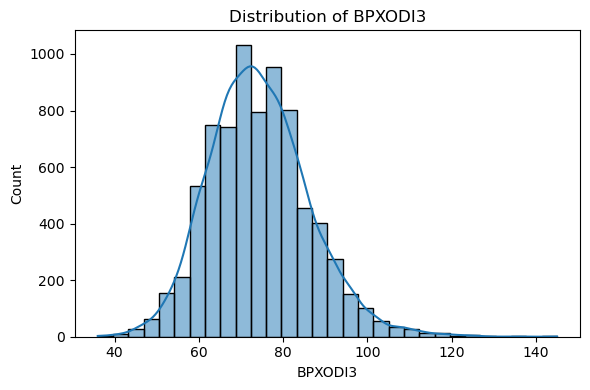

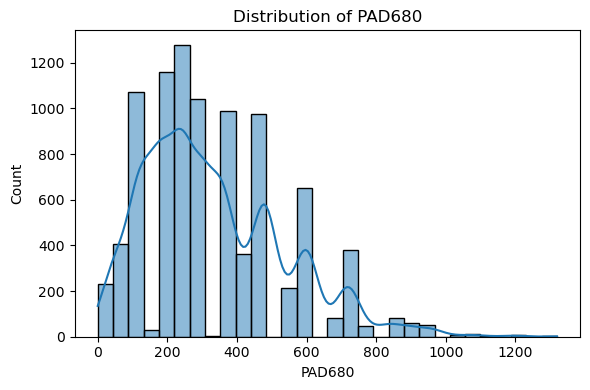

In [16]:
# Histograms for numeric features

for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(figures_dir / f"hist_{col}.png", dpi=150)
    plt.show()

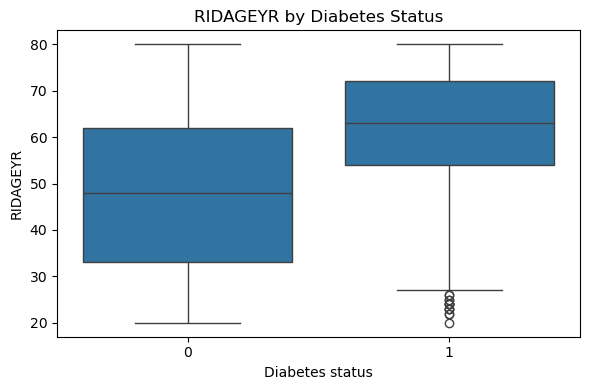

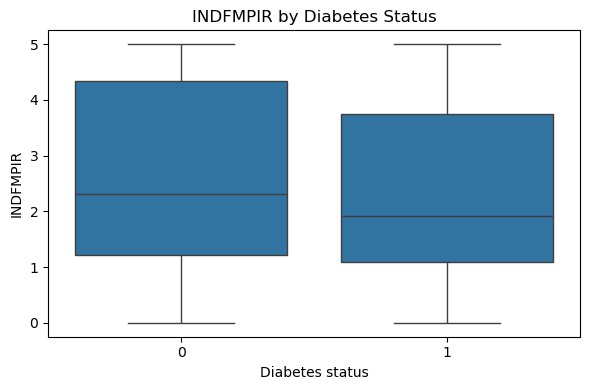

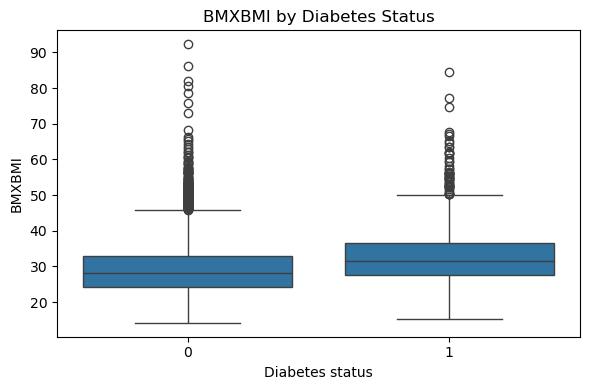

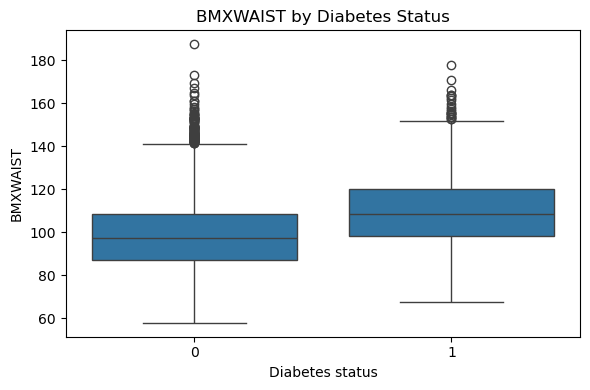

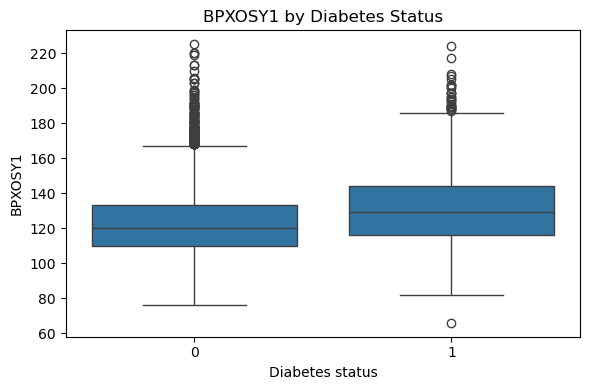

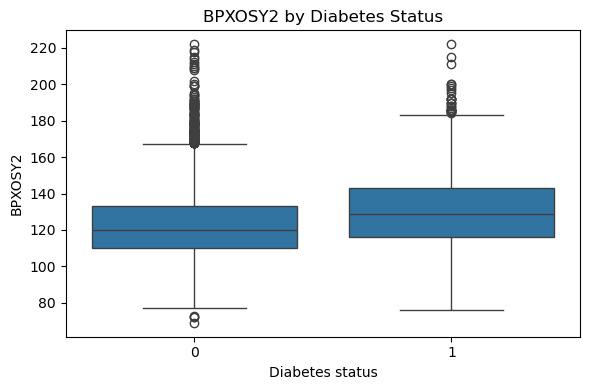

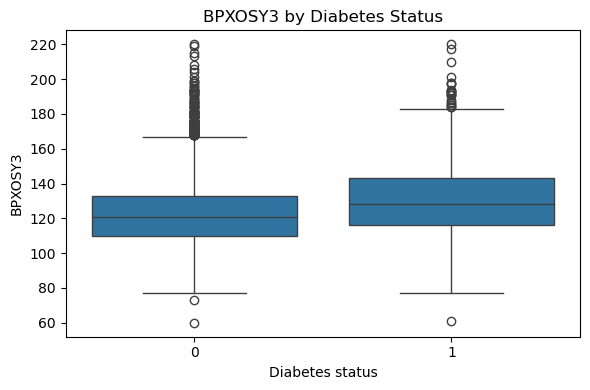

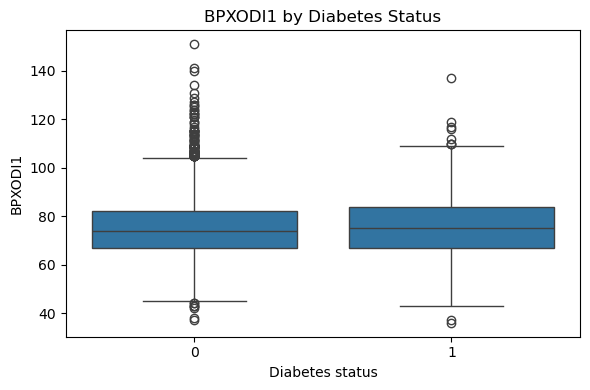

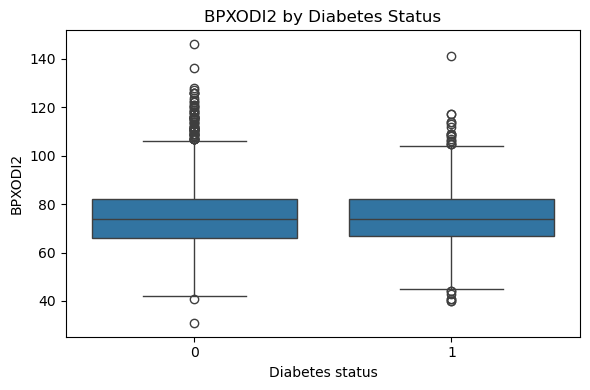

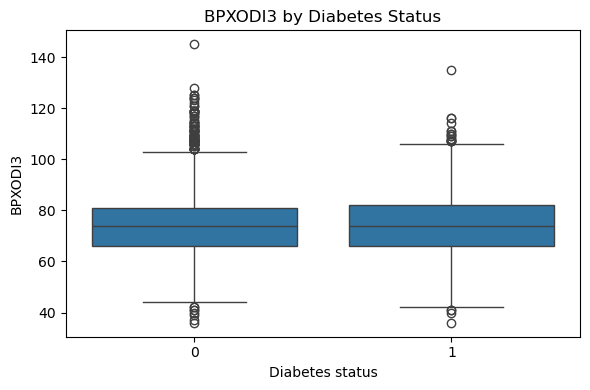

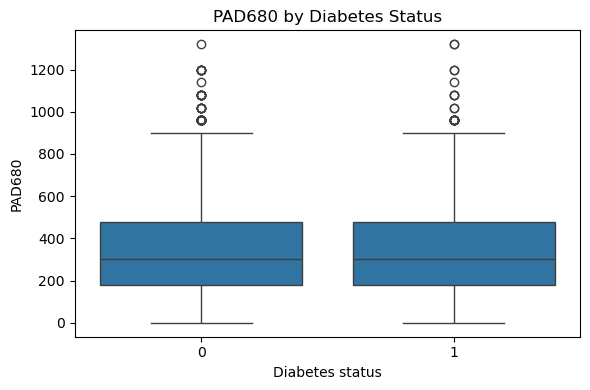

In [17]:
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="diabetes", y=col)
    plt.title(f"{col} by Diabetes Status")
    plt.xlabel("Diabetes status")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(figures_dir / f"boxplot_{col}_by_diabetes.png", dpi=150)
    plt.show()

In [18]:
from PIL import Image, ImageOps, ImageDraw
from pathlib import Path
import math

figures_dir = Path.home() / "Documents" / "diabetes-risk-project" / "results" / "figures"

# Get png files, but do NOT include previous combined grid images
image_files = sorted([
    p for p in figures_dir.glob("*.png")
    if "all_eda_plots_grid" not in p.name
])

print("Number of images:", len(image_files))

# Grid settings
n_cols = 3
thumb_width = 450
thumb_height = 320
title_height = 35
padding = 20

n_rows = math.ceil(len(image_files) / n_cols)

cell_width = thumb_width + 2 * padding
cell_height = thumb_height + title_height + 2 * padding

grid_width = n_cols * cell_width
grid_height = n_rows * cell_height

combined = Image.new("RGB", (grid_width, grid_height), "white")
draw = ImageDraw.Draw(combined)

for i, image_path in enumerate(image_files):
    img = Image.open(image_path).convert("RGB")
    
    # Resize image to fit inside fixed thumbnail box
    img.thumbnail((thumb_width, thumb_height))
    
    row = i // n_cols
    col = i % n_cols
    
    x = col * cell_width + padding
    y = row * cell_height + padding
    
    # Add title
    draw.text((x, y), image_path.name, fill="black")
    
    # Center image inside thumbnail box
    img_x = x + (thumb_width - img.width) // 2
    img_y = y + title_height + (thumb_height - img.height) // 2
    
    combined.paste(img, (img_x, img_y))

output_path = figures_dir / "all_eda_plots_grid.png"
combined.save(output_path)

output_path

Number of images: 22


PosixPath('/Users/shirinalimirzaei/Documents/diabetes-risk-project/results/figures/all_eda_plots_grid.png')

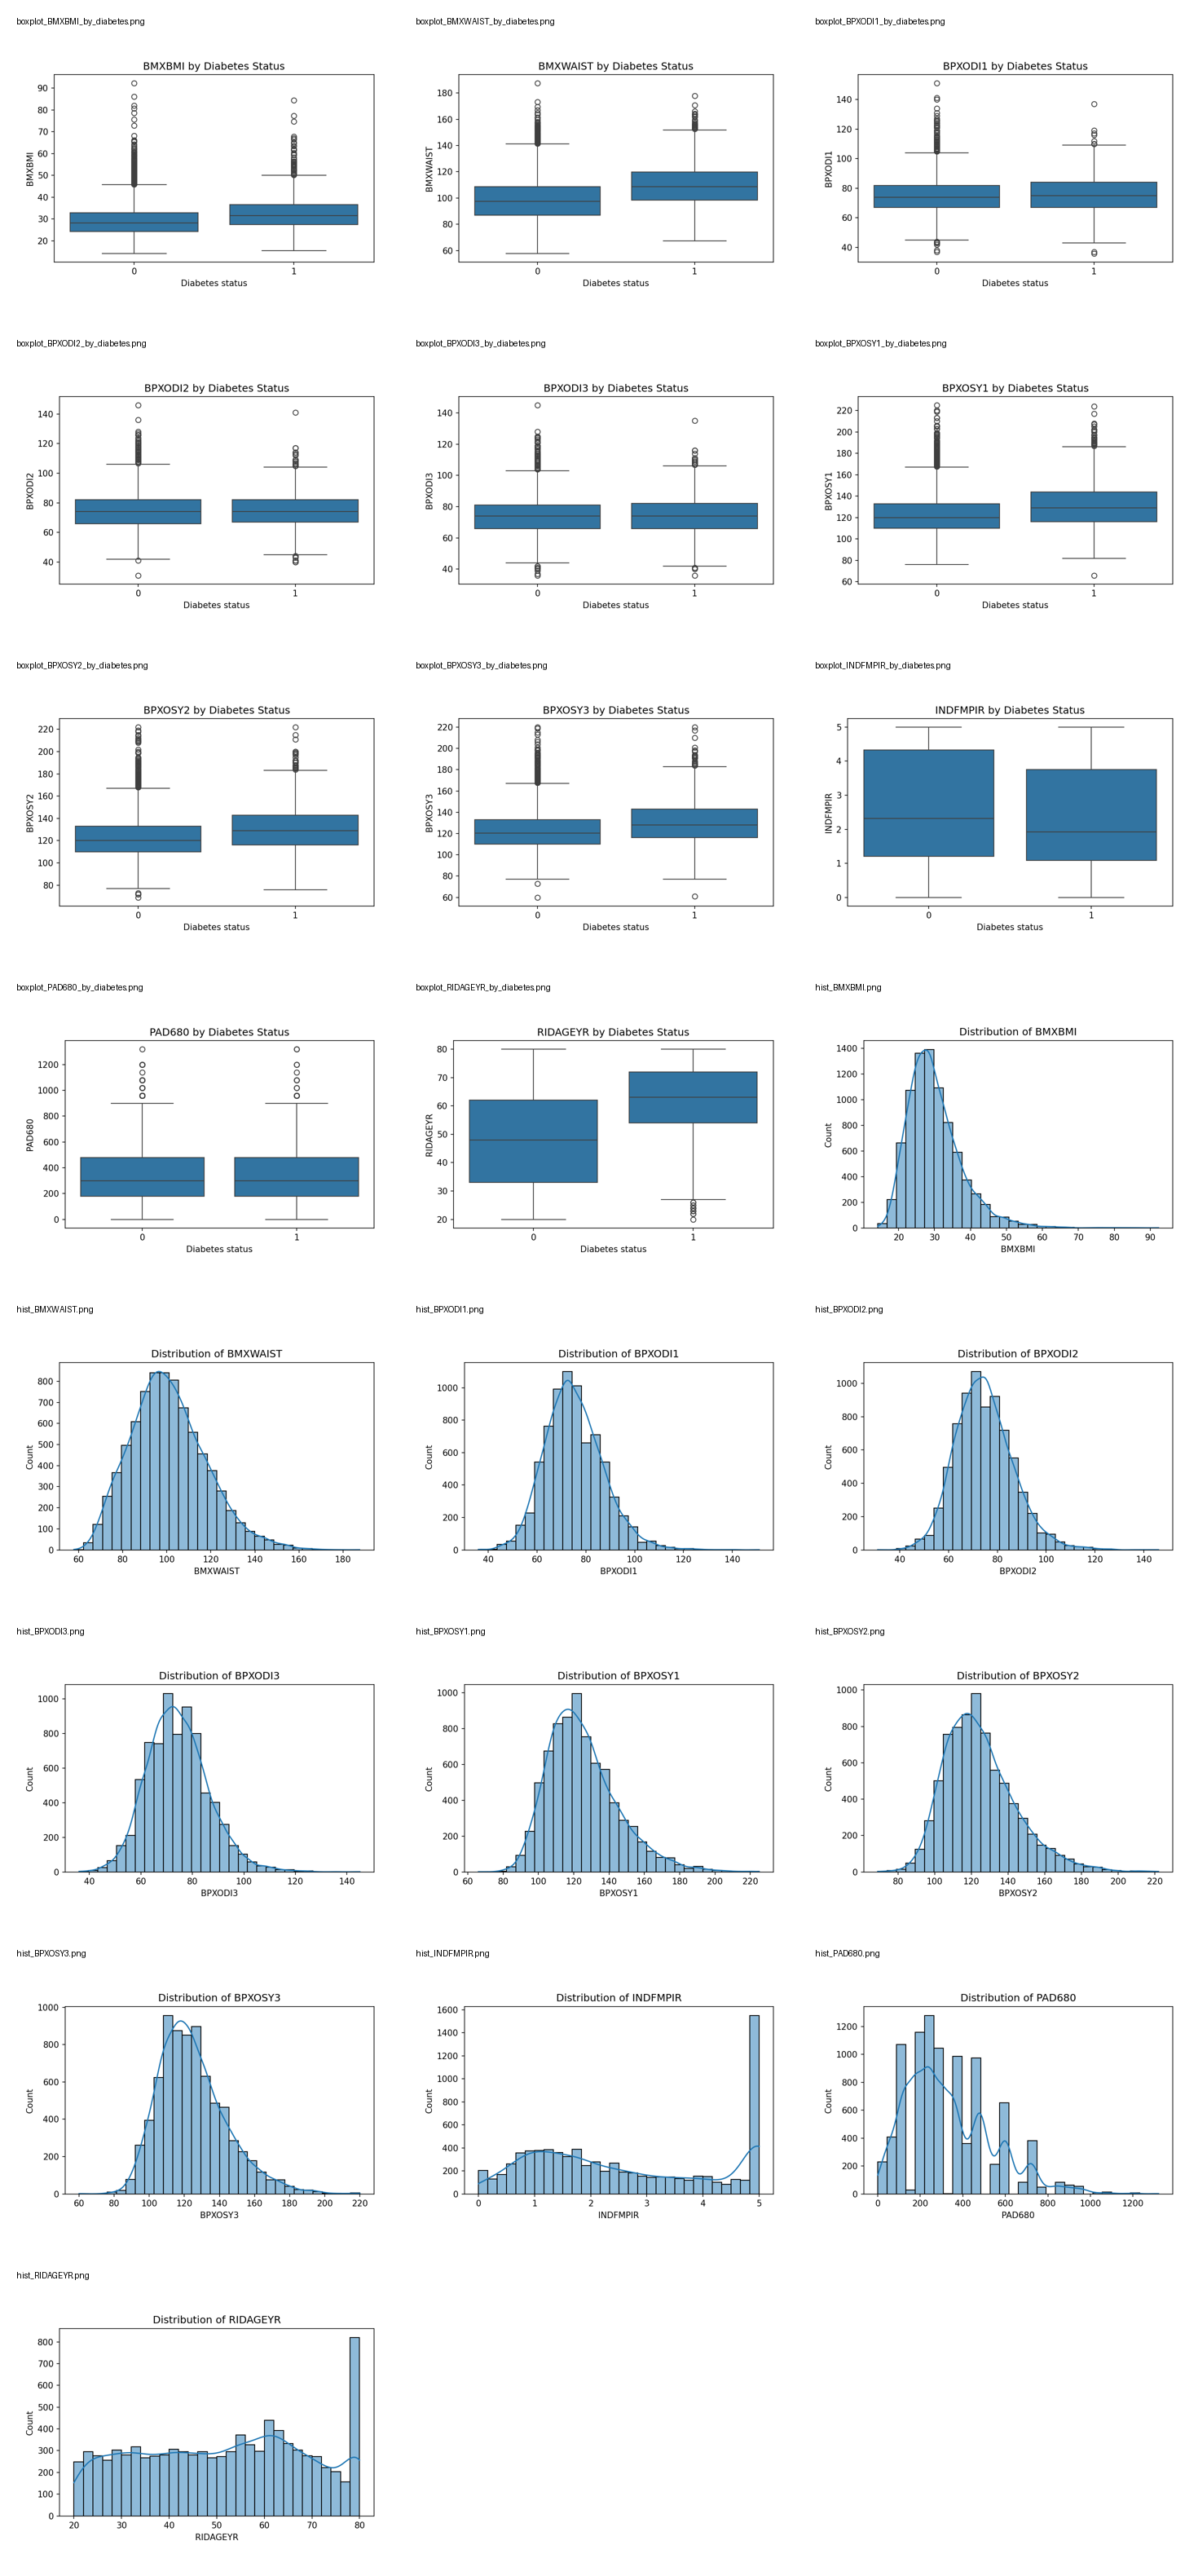

In [19]:
from IPython.display import Image, display

display(Image(filename=output_path, width=1200))

### Main EDA findings from the plots:
The diabetes group seems to have higher BMI and higher waist circumference. 
In the boxplots, the median for BMXBMI and BMXWAIST is clearly higher for diabetes = 1.

The diabetes group also seems to be older. 
The RIDAGEYR boxplot shows the diabetes group has a higher median age than the non-diabetes group.

Systolic blood pressure variables, especially BPXOSY1, BPXOSY2, and BPXOSY3, appear slightly higher for the diabetes group. 
This suggests blood pressure may be useful for prediction.

Diastolic blood pressure variables, BPXODI1, BPXODI2, and BPXODI3, look more similar between groups.
They may still be useful, but the difference is not as obvious as BMI, waist, age, or systolic pressure.

INDFMPIR may be lower for the diabetes group, but the difference is not extremely large from the boxplot.

PAD680 has a wide distribution and many repeated values.
It may still be useful, but it looks more irregular than BMI or blood pressure.


### Univariate Distribution and Boxplot Findings
The EDA plots show several visible differences between participants with and without diabetes. 
Participants with diabetes tend to have higher BMI, higher waist circumference, and higher age. 
Systolic blood pressure measurements also appear somewhat higher in the diabetes group.
Diastolic blood pressure measurements are more similar across the two groups.


The histograms show that BMI and waist circumference are right-skewed, with some high-value outliers. 
Blood pressure variables are approximately bell-shaped but also contain outliers. 
Sedentary time (`PAD680`) has an irregular distribution with repeated values, 
likely because participants report activity time in rounded amounts.

These findings suggest that age, BMI, waist circumference, and systolic blood pressure 
may be important predictors for diabetes risk screening.

In [20]:
!pip install missingno

In [21]:
# Missingno visualizations

import missingno as msno

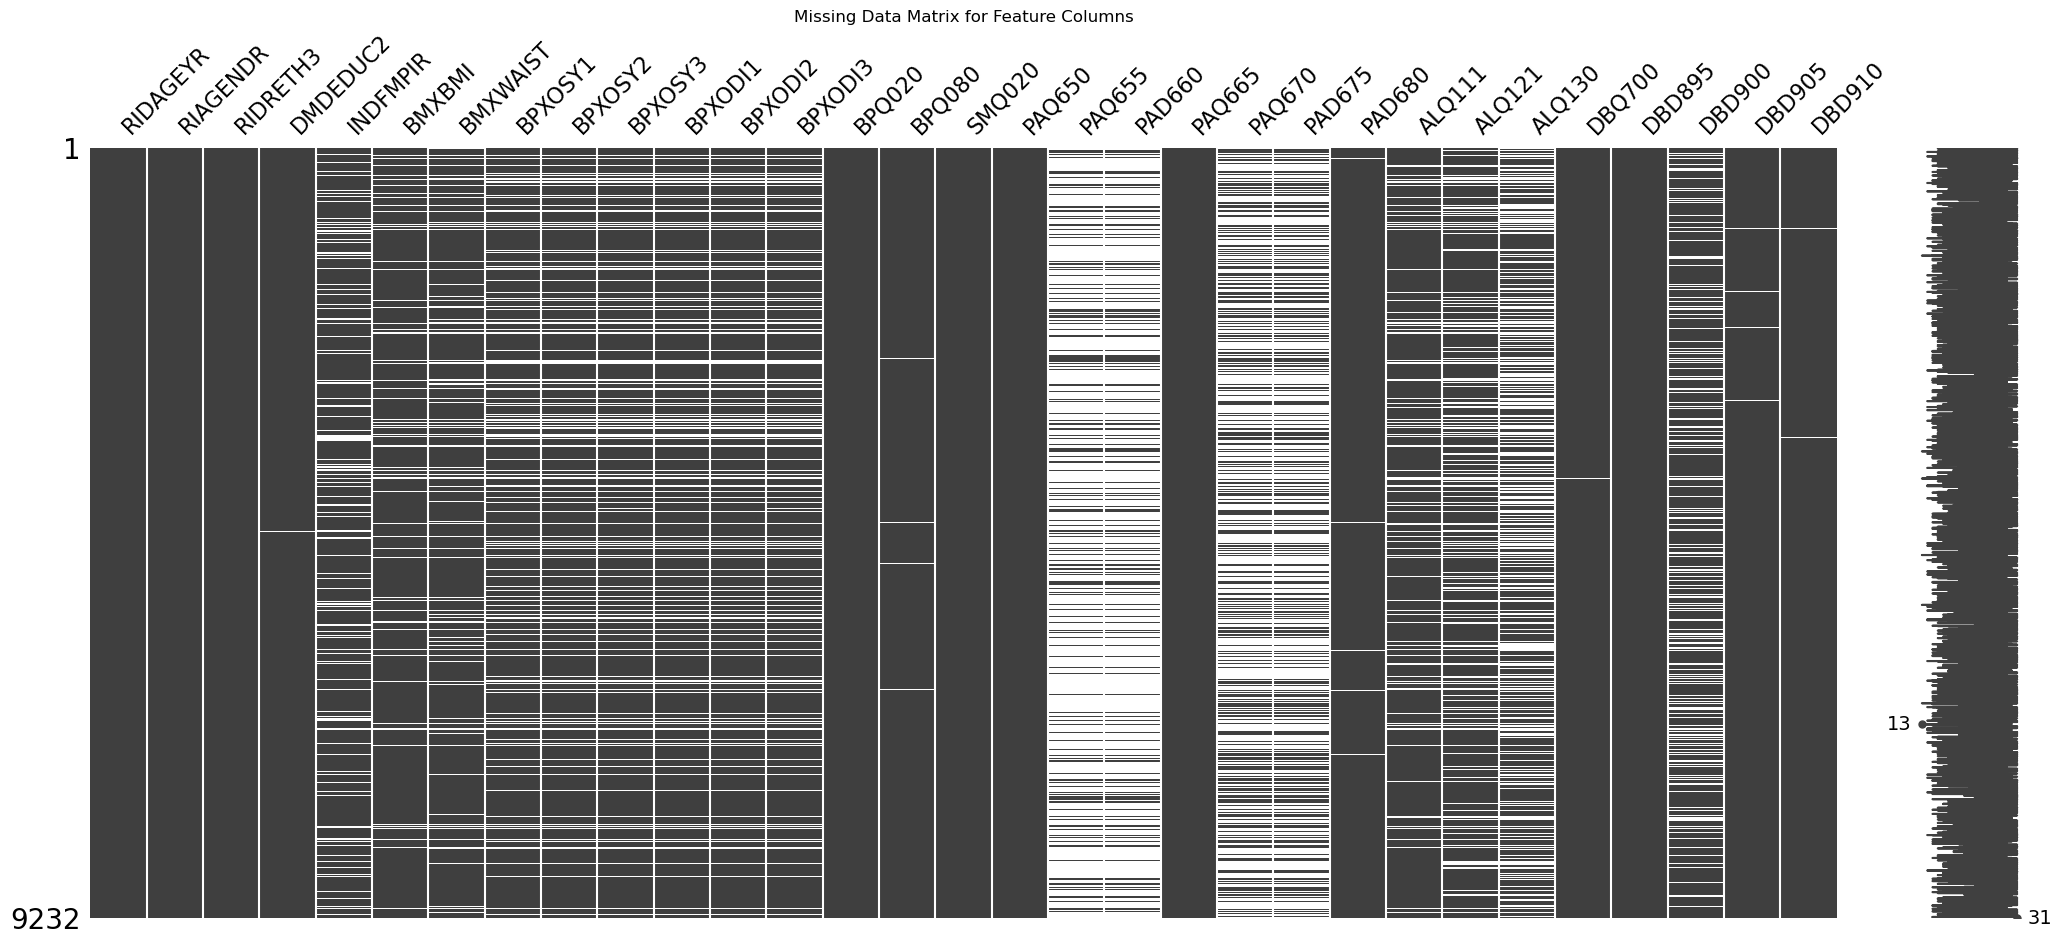

In [22]:
# Missing data matrix
msno.matrix(df[feature_cols])
plt.title("Missing Data Matrix for Feature Columns")
plt.show()

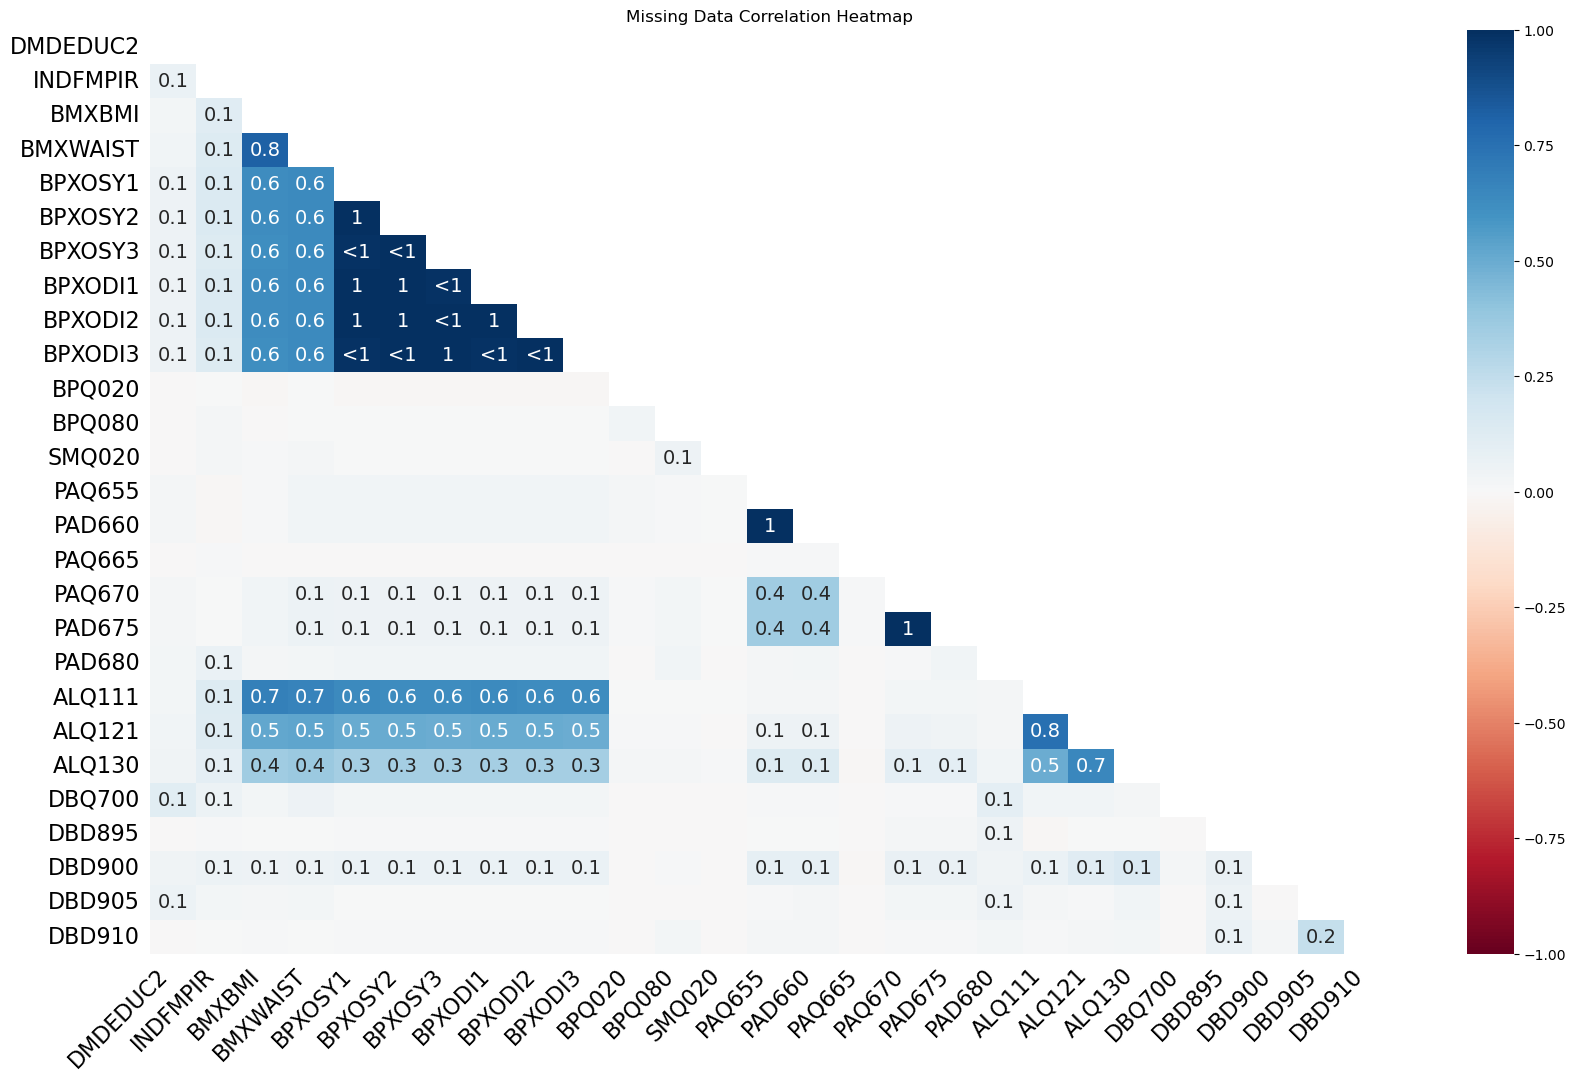

In [23]:
# Missing data heatmap
msno.heatmap(df[feature_cols])
plt.title("Missing Data Correlation Heatmap")
plt.show()

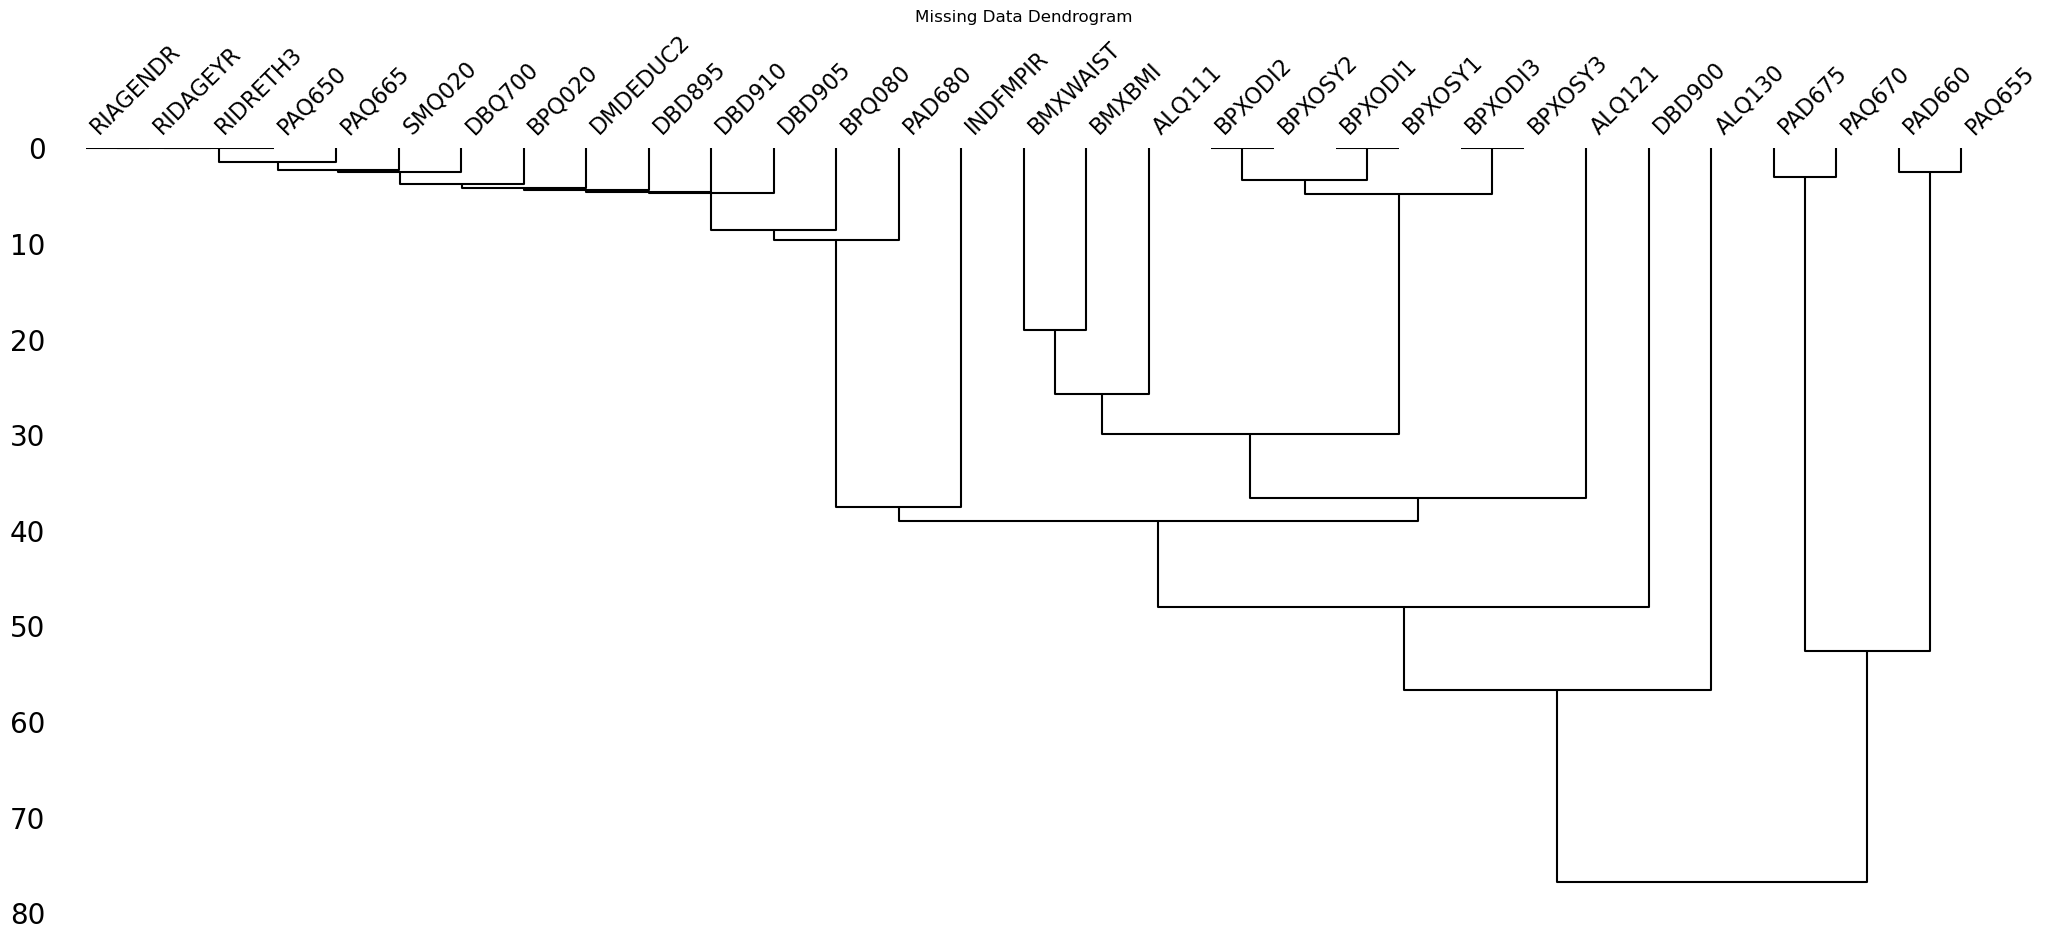

In [24]:
# Missing data dendrogram
msno.dendrogram(df[feature_cols])
plt.title("Missing Data Dendrogram")
plt.show()

### Missingno Visualization Findings

The missing data matrix confirms that missingness is concentrated in several feature groups,
especially physical activity, alcohol, diet, and examination-related variables. 
The missingness heatmap and dendrogram show that some variables have similar missing-value patterns.
This is expected for variables collected within the same NHANES module or variables that depend on follow-up questions.

For example, blood pressure measurements have similar missingness patterns
because they come from the same examination module. 
Physical activity variables such as `PAQ655`, `PAD660`, `PAQ670`, and `PAD675` 
are also related because duration variables are often collected only when participants report doing the activity.

These results suggest that missingness is not completely random. Therefore, later modeling 
should use imputation and possibly missing-value indicators rather than simply dropping rows with missing data.


## 6. Low-information Features

In [25]:
# Low-information feature check

low_info_summary = pd.DataFrame({
    "n_unique": df[feature_cols].nunique(dropna=True),
    "missing_percent": df[feature_cols].isna().mean() * 100
}).sort_values(["n_unique", "missing_percent"])

low_info_summary

,n_unique,missing_percent
RIAGENDR,2,0.000000
PAQ650,2,0.000000
PAQ665,2,0.021664
SMQ020,2,0.054159
BPQ020,2,0.129983
BPQ080,2,0.714905
ALQ111,2,13.594021
DBQ700,5,0.054159
DMDEDUC2,5,0.162478
RIDRETH3,6,0.000000


In [26]:
# Check dominant value percentage for each feature
#(This tells us if one value appears almost all the time.)

dominant_value_summary = []

for col in feature_cols:
    value_counts = df[col].value_counts(normalize=True, dropna=True)
    
    if len(value_counts) > 0:
        dominant_value = value_counts.index[0]
        dominant_percent = value_counts.iloc[0] * 100
    else:
        dominant_value = np.nan
        dominant_percent = np.nan
    
    dominant_value_summary.append({
        "feature": col,
        "n_unique": df[col].nunique(dropna=True),
        "dominant_value": dominant_value,
        "dominant_percent": dominant_percent,
        "missing_percent": df[col].isna().mean() * 100
    })

dominant_value_summary = pd.DataFrame(dominant_value_summary)

dominant_value_summary.sort_values("dominant_percent", ascending=False)

,feature,n_unique,dominant_value,dominant_percent,missing_percent
23,ALQ111,2,1.000000e+00,90.698257,13.594021
16,PAQ650,2,2.000000e+00,76.256499,0.000000
14,BPQ080,2,2.000000e+00,64.422867,0.714905
30,DBD910,39,5.397605e-79,62.391493,0.173310
29,DBD905,36,5.397605e-79,61.627781,0.184142
13,BPQ020,2,2.000000e+00,61.355748,0.129983
19,PAQ665,2,2.000000e+00,59.826652,0.021664
15,SMQ020,2,2.000000e+00,58.263791,0.054159
1,RIAGENDR,2,2.000000e+00,51.483969,0.000000
26,DBQ700,5,3.000000e+00,38.950905,0.054159


In [27]:
### Low-information Feature Findings

Low-information features were checked using the number of unique values, 
missingness percentage, and dominant value percentage.

Several variables have only two unique values, such as `RIAGENDR`, `PAQ650`,
`PAQ665`, `SMQ020`, `BPQ020`, `BPQ080`, and `ALQ111`. These variables were not removed
because they represent meaningful binary or categorical survey responses.

No feature was truly near-constant based on the dominant value check.
The highest dominant value percentage was for `ALQ111`, but it was still below 95%,
so it was not removed at this stage.

Some features have high missingness, especially `PAD660`, `PAQ655`, `PAD675`,
and `PAQ670`. These variables are related to physical activity and may be missing
because of NHANES survey skip patterns or follow-up questions. Therefore, they were not 
automatically dropped during EDA. Later modeling should consider imputation,
missing-value indicators, or sensitivity checks for these high-missingness variables.

SyntaxError: invalid syntax (3217013734.py, line 3)

### Low-information Feature Findings

Low-information features were checked using the number of unique values,
missingness percentage, and dominant value percentage.

Several variables have only two unique values, such as `RIAGENDR`, `PAQ650`,
`PAQ665`, `SMQ020`, `BPQ020`, `BPQ080`, and `ALQ111`. These are not removed 
because they represent meaningful binary or categorical survey responses.

No feature appears to be truly near-constant using the dominant value check.
The highest dominant value percentage was for `ALQ111`, but it was still below 95%, 
so it was not removed at this stage.

Some features have high missingness, especially `PAD660`, `PAQ655`, `PAD675`,
and `PAQ670`. These variables are related to physical activity and may be missing 
due to survey skip patterns or follow-up questions. Therefore, they were not
automatically dropped during EDA. Later modeling should consider imputation,
missing-value indicators, or sensitivity checks for these high-missingness variables.

## 7. Redundancy Checks

In [ ]:
# Redundancy check using correlation matrix

numeric_feature_df = df[numeric_features].copy()

corr_numeric = numeric_feature_df.corr().abs()

# Find highly correlated feature pairs
upper_triangle = corr_numeric.where(
    np.triu(np.ones(corr_numeric.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["correlation"] > 0.85
].sort_values("correlation", ascending=False)

high_corr_pairs

### Redundancy Check Findings

The correlation-based redundancy check identified several highly correlated feature pairs. 
The repeated systolic blood pressure measurements (`BPXOSY1`, `BPXOSY2`, and `BPXOSY3`) 
were strongly correlated with each other. The repeated diastolic blood pressure measurements 
(`BPXODI1`, `BPXODI2`, and `BPXODI3`) were also strongly correlated.

BMI (`BMXBMI`) and waist circumference (`BMXWAIST`) were also highly correlated,
    which is expected because both variables measure body size and adiposity.

These features were not dropped immediately during EDA. Instead, feature engineering 
    can be used later to create average systolic and diastolic blood pressure variables, 
reducing redundancy while preserving clinical information. For BMI and waist circumference, 
both may still be considered because they represent related but not identical health measures.

In [ ]:
# Redundancy check using VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Use numeric features only
X_vif = df[numeric_features].copy()

# Impute missing values with median
imputer = SimpleImputer(strategy="median")
X_vif_imputed = imputer.fit_transform(X_vif)

# Scale features
scaler = StandardScaler()
X_vif_scaled = scaler.fit_transform(X_vif_imputed)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_features
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_scaled, i)
    for i in range(X_vif_scaled.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

### VIF Findings

The VIF results show high multicollinearity among the repeated blood pressure measurements.
The systolic blood pressure variables (`BPXOSY1`, `BPXOSY2`, `BPXOSY3`) have high VIF values, 
and the diastolic blood pressure variables (`BPXODI1`, `BPXODI2`, `BPXODI3`) also show 
elevated VIF values. This is expected because these variables are repeated measurements 
from the same examination.

BMI (`BMXBMI`) and waist circumference (`BMXWAIST`) show moderate redundancy, 
but both may still be clinically meaningful because they measure related but not 
identical aspects of body size.

At this EDA stage, these variables are not removed immediately. Later feature engineering
can reduce redundancy by creating average systolic and average diastolic blood pressure variables.

## 8. Relationships Between Variables

In [ ]:
# Correlation heatmap for numeric features and diabetes target

corr_cols = numeric_features + ["diabetes"]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap for Numeric Features and Diabetes")
plt.tight_layout()
plt.show()

In [ ]:
# Correlation with diabetes target

diabetes_corr = corr_matrix["diabetes"].drop("diabetes").sort_values(key=abs, ascending=False)

diabetes_corr

### Correlation Findings

The correlation heatmap shows that age (`RIDAGEYR`) has the strongest numeric correlation
with diabetes among the selected numeric features. Waist circumference (`BMXWAIST`),
BMI (`BMXBMI`), and systolic blood pressure measurements (`BPXOSY1`, `BPXOSY2`, `BPXOSY3`) 
also show positive correlations with diabetes.

The repeated blood pressure measurements are highly correlated with each other,
which is expected because they measure the same clinical quantity. BMI and waist 
circumference are also strongly correlated. These results suggest that feature
engineering, such as creating average systolic and diastolic blood pressure 
variables, may help simplify the predictor set.

Diastolic blood pressure and sedentary time show weak correlations with diabetes in this dataset.

In [ ]:
# Scatterplots for relationships between important numeric variables

scatter_pairs = [
    ("BMXBMI", "BMXWAIST"),
    ("RIDAGEYR", "BMXBMI"),
    ("RIDAGEYR", "BMXWAIST"),
    ("RIDAGEYR", "BPXOSY1"),
    ("BMXBMI", "BPXOSY1")
]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="diabetes",
        alpha=0.4
    )
    plt.title(f"{y_col} vs {x_col} by Diabetes Status")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

In [ ]:
# Scatterplots using a sample to reduce overplotting and make points smaller with s=20

df_sample = df.sample(n=2000, random_state=42)

scatter_pairs = [
    ("BMXBMI", "BMXWAIST"),
    ("RIDAGEYR", "BMXBMI"),
    ("RIDAGEYR", "BMXWAIST"),
    ("RIDAGEYR", "BPXOSY1"),
    ("BMXBMI", "BPXOSY1")
]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=df_sample,
        x=x_col,
        y=y_col,
        hue="diabetes",
        alpha=0.5,
        s=20
    )
    plt.title(f"{y_col} vs {x_col} by Diabetes Status")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()


### Scatterplot Findings

The scatterplots show a strong positive relationship between BMI (`BMXBMI`) 
and waist circumference (`BMXWAIST`). This is expected because both variables
measure body size and adiposity.

The diabetes group appears more concentrated among older participants.
Scatterplots involving age show more diabetes cases at higher ages, which is
consistent with the correlation and group summary results.

Systolic blood pressure (`BPXOSY1`) tends to increase with age. However, 
the diabetes and non-diabetes groups overlap substantially in most scatterplots, 
meaning no single numeric variable perfectly separates the two classes.

The relationship between BMI and systolic blood pressure is weaker and more scattered. 
There are also visible outliers in BMI, waist circumference, and blood pressure, which
should be checked during outlier analysis.



In [ ]:
# Summary statistics by diabetes status for numeric features

eda_summary = df.groupby("diabetes")[numeric_features].agg(["mean", "median", "std", "count"])

eda_summary

In [ ]:
# Difference in means between diabetes and non-diabetes groups

group_means = df.groupby("diabetes")[numeric_features].mean().T

group_means.columns = ["non_diabetes_mean", "diabetes_mean"]

group_means["difference"] = group_means["diabetes_mean"] - group_means["non_diabetes_mean"]
group_means["absolute_difference"] = group_means["difference"].abs()

group_means.sort_values("absolute_difference", ascending=False)

### Numeric Feature Differences by Diabetes Status

The group summary shows that participants with diabetes are older on average than participants without diabetes. 
The diabetes group also has higher mean waist circumference, BMI, and systolic blood pressure.
These differences are consistent with the boxplot findings.

The largest mean difference appears for sedentary time (`PAD680`), but this variable has a wide and 
irregular distribution, so it should be interpreted carefully. 
Income-to-poverty ratio (`INDFMPIR`) is slightly lower on average among participants with diabetes.

## 9. Model-based Diagnostics


In [29]:
# Model-based diagnostics using Random Forest feature importance

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split

# Use selected feature columns and target
X = df[feature_cols].copy()
y = df[target_col].copy()

# Make sure no temporary EDA columns are included
X = X.drop(columns=["isolation_outlier"], errors="ignore")

# Train-test split for diagnostic model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Impute missing values using median
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)

# Random Forest model for feature importance
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_imputed, y_train)

# Feature importance table
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
0,RIDAGEYR,0.128573
6,BMXWAIST,0.090483
5,BMXBMI,0.069474
13,BPQ020,0.053060
4,INDFMPIR,0.047922
7,BPXOSY1,0.042183
9,BPXOSY3,0.041943
8,BPXOSY2,0.041358
12,BPXODI3,0.037953
22,PAD680,0.037915


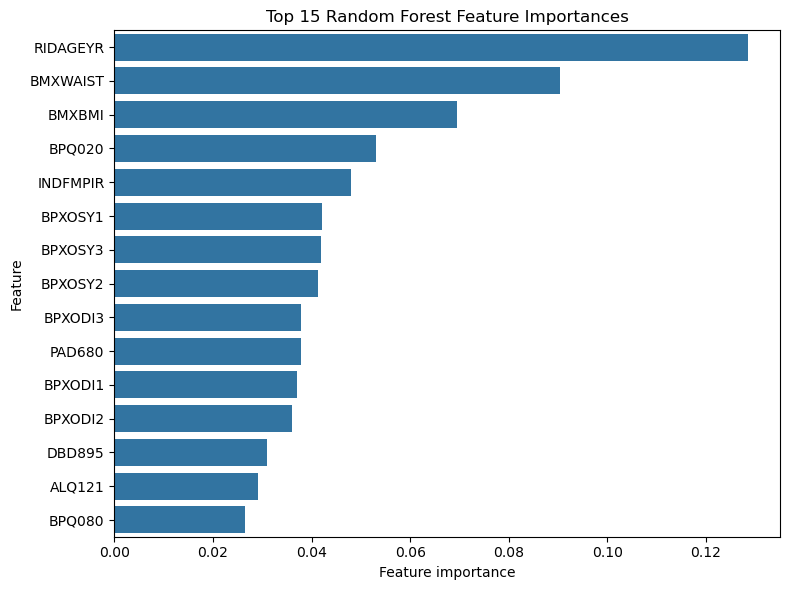

In [30]:
# Top 15 Random Forest feature importances

top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [32]:
# SelectFromModel using Random Forest

selector = SelectFromModel(
    rf_model,
    threshold="median",
    prefit=True
)

selected_mask = selector.get_support()

selected_features_model = X_train.columns[selected_mask].tolist()

print("Number of features selected by SelectFromModel:", len(selected_features_model))
selected_features_model

Number of features selected by SelectFromModel: 16


['RIDAGEYR',
 'RIDRETH3',
 'INDFMPIR',
 'BMXBMI',
 'BMXWAIST',
 'BPXOSY1',
 'BPXOSY2',
 'BPXOSY3',
 'BPXODI1',
 'BPXODI2',
 'BPXODI3',
 'BPQ020',
 'BPQ080',
 'PAD680',
 'ALQ121',
 'DBD895']

### Model-based Diagnostic Findings

A Random Forest model was used as a model-based diagnostic tool to examine feature importance.
This step was used only as supporting evidence and not as the main feature-selection method.

The most important features included age (`RIDAGEYR`), waist circumference (`BMXWAIST`),
BMI (`BMXBMI`), high blood pressure history (`BPQ020`), income-to-poverty ratio (`INDFMPIR`),
and systolic blood pressure measurements (`BPXOSY1`, `BPXOSY2`, `BPXOSY3`). 
These results are consistent with the earlier EDA findings, where age, body size,
and blood pressure showed noticeable relationships with diabetes status.

`SelectFromModel` selected 16 features using the fitted Random Forest model and
a median importance threshold. These selected features provide supporting evidence
for which variables may be useful in modeling. However, they are not used as 
the only basis for feature selection because model-based importance can be affected
by correlated features, missingness patterns, and model assumptions.

Overall, the model-based diagnostics support the earlier domain knowledge, correlation, 
and group-summary findings.

## 10. Outlier Detection

In [33]:
# Outlier detection using z-scores

outlier_features = [
    "RIDAGEYR",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI2", "BPXODI3",
    "PAD680"
]

outlier_features = [col for col in outlier_features if col in df.columns]

# Use only complete rows for z-score calculation
df_outlier = df[outlier_features].copy()

z_scores = df_outlier.apply(lambda x: zscore(x, nan_policy="omit"))

# Mark values with absolute z-score greater than 3
z_outliers = (z_scores.abs() > 3)

z_outlier_counts = z_outliers.sum().sort_values(ascending=False)

z_outlier_counts

BMXBMI      109
PAD680       86
BPXOSY1      79
BPXOSY2      75
BPXOSY3      69
BPXODI2      59
BPXODI3      54
BMXWAIST     51
BPXODI1      51
RIDAGEYR      0
INDFMPIR      0
dtype: int64

In [34]:
# Percentage of z-score outliers by feature

z_outlier_summary = pd.DataFrame({
    "outlier_count": z_outlier_counts,
    "outlier_percent": z_outlier_counts / len(df) * 100
})

z_outlier_summary

,outlier_count,outlier_percent
BMXBMI,109,1.180676
PAD680,86,0.931542
BPXOSY1,79,0.855719
BPXOSY2,75,0.812392
BPXOSY3,69,0.747400
BPXODI2,59,0.639081
BPXODI3,54,0.584922
BMXWAIST,51,0.552426
BPXODI1,51,0.552426
RIDAGEYR,0,0.000000


In [35]:
# Rows with at least one z-score outlier

rows_with_z_outlier = z_outliers.any(axis=1)

print("Number of rows with at least one z-score outlier:", rows_with_z_outlier.sum())
print("Percentage of rows with at least one z-score outlier:", rows_with_z_outlier.mean() * 100)

Number of rows with at least one z-score outlier: 362
Percentage of rows with at least one z-score outlier: 3.921143847487002


### Z-score Outlier Findings

Using an absolute z-score threshold greater than 3, the largest number
of outliers appeared in BMI (`BMXBMI`), sedentary time (`PAD680`), 
and blood pressure variables. Overall, 362 rows, or about 3.9% of the 
dataset, contain at least one z-score outlier among the selected numeric features.

These outliers are not removed at this stage because they may represent real clinical 
or behavioral values rather than data errors. Later modeling should use preprocessing 
steps that are robust to extreme values, especially for linear models.

In [36]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [37]:
# Prepare data for Isolation Forest

X_outlier = df[outlier_features].copy()

# Impute missing numeric values using median
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_outlier)

# Scale features before Isolation Forest
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

I choose contamination=0.04 because my z-score method found about 3.9% 
rows with at least one z-score outlier.

In [38]:
# Isolation Forest outlier detection

iso_forest = IsolationForest(contamination=0.04,
                            random_state=42)

isolation_labels = iso_forest.fit_predict(X_scaled)

# In IsolationForest:
#  1 means normal
# -1 means outlier

df_iso = df.copy()
df_iso["isolation_outlier"] = isolation_labels


df_iso["isolation_outlier"].value_counts()

isolation_outlier
 1    8862
-1     370
Name: count, dtype: int64

In [39]:
# Isolation Forest outlier summary

n_iso_outliers = (df_iso["isolation_outlier"] == -1).sum()
percent_iso_outliers = (df_iso["isolation_outlier"] == -1).mean() * 100

print("Number of Isolation Forest outliers:", n_iso_outliers)
print("Percentage of Isolation Forest outliers:", percent_iso_outliers)

Number of Isolation Forest outliers: 370
Percentage of Isolation Forest outliers: 4.007798960138649


In [40]:
# Isolation Forest outliers by diabetes status

pd.crosstab(df_iso["diabetes"],
            df_iso["isolation_outlier"],
            normalize="index") * 100

isolation_outlier,-1,1
diabetes,,
0,3.480842,96.519158
1,6.153846,93.846154


## Isolation Forest Outlier Findings

Isolation Forest identified 370 rows as outliers, which is about 4.0% of the dataset. 
This is consistent with the contamination value of 0.04 used in the model.

When comparing outliers by diabetes status, about 3.5% of non-diabetes participants were 
classified as outliers, compared with about 6.2% of diabetes participants. This suggests
that participants with diabetes are more likely to have unusual combinations of numeric features.

These observations are not removed at this stage. Since this is health data, extreme values may 
represent real clinical cases rather than data errors. The outlier results will mainly be used 
to understand the data and to guide preprocessing choices for modeling.

## 11. <span style= "color:red"> Time-series and Lag Structure<\span>


This dataset is **cross-sectional** rather than longitudinal or time-series.
Each row represents a different NHANES participant, and participants are not 
repeatedly measured over ordered time points in this processed dataset.

Because there is no true time variable or repeated measurements for the same participant,
lag features using `pandas.DataFrame.shift()` would not have a meaningful interpretation. 
Applying autocorrelation or partial autocorrelation methods such as `plot_acf` or `plot_pacf` 
would also not be appropriate, because the row order does not represent time.

Therefore, ***time-series lag analysis was not performed***. 
The analysis instead focuses on ***cross-sectional*** relationships between demographic, clinical, lifestyle, and diabetes-related variables.


## 12. Feature Engineering

Feature engineering was guided by the EDA findings, domain knowledge, and redundancy checks.
The goal is to create interpretable features that may improve modeling while avoiding
unnecessary feature expansion.


In [43]:
# Create a copy of the dataset for feature engineering

df_fe = df.copy()

print("Original shape:", df.shape)
print("Feature engineering dataset shape:", df_fe.shape)

Original shape: (9232, 37)
Feature engineering dataset shape: (9232, 37)


In [44]:
# Average blood pressure features

systolic_cols = ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
diastolic_cols = ["BPXODI1", "BPXODI2", "BPXODI3"]

df_fe["avg_systolic_bp"] = df_fe[systolic_cols].mean(axis=1)
df_fe["avg_diastolic_bp"] = df_fe[diastolic_cols].mean(axis=1)

df_fe[[
    "BPXOSY1", "BPXOSY2", "BPXOSY3", "avg_systolic_bp",
    "BPXODI1", "BPXODI2", "BPXODI3", "avg_diastolic_bp"
]].head()

,BPXOSY1,BPXOSY2,BPXOSY3,avg_systolic_bp,BPXODI1,BPXODI2,BPXODI3,avg_diastolic_bp
0,99.0,99.0,99.0,99.000000,56.0,55.0,52.0,54.333333
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,102.0,108.0,111.0,107.000000,65.0,68.0,68.0,67.000000
3,116.0,110.0,115.0,113.666667,68.0,66.0,68.0,67.333333
4,138.0,132.0,132.0,134.000000,70.0,69.0,71.0,70.000000


### Average Blood Pressure Features

The redundancy checks showed that repeated systolic blood pressure measurements 
were highly correlated with each other. The same pattern appeared for repeated 
diastolic blood pressure measurements.

To reduce redundancy while preserving clinical information, average systolic blood 
pressure and average diastolic blood pressure features were created.

In [46]:
# BMI category feature

df_fe["bmi_category"] = pd.cut(
    df_fe["BMXBMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["underweight", "normal", "overweight", "obese"]
)

df_fe[["BMXBMI", "bmi_category"]].head(10)

,BMXBMI,bmi_category
0,37.8,obese
1,NaN,NaN
2,29.7,overweight
3,21.9,normal
4,30.2,obese
5,26.6,overweight
6,NaN,NaN
7,39.1,obese
8,28.9,overweight
9,28.1,overweight


In [47]:
# BMI category distribution by diabetes status

pd.crosstab(
    df_fe["bmi_category"],
    df_fe["diabetes"],
    normalize="columns"
) * 100

diabetes,0,1
bmi_category,,
underweight,1.848539,0.298864
normal,27.564103,12.313210
overweight,32.513417,28.870293
obese,38.073942,58.517633


### BMI Category Feature

BMI was converted into clinically interpretable categories: underweight, normal, overweight, and obese. This feature may help capture nonlinear relationships between body size and diabetes risk while keeping the feature interpretable.

The distribution shows that a higher percentage of participants with diabetes are in the obese BMI category compared with participants without diabetes. This supports the earlier EDA finding that BMI is associated with diabetes status.

In [48]:
# Age group feature

df_fe["age_group"] = pd.cut(
    df_fe["RIDAGEYR"],
    bins=[20, 35, 50, 65, np.inf],
    labels=["20-34", "35-49", "50-64", "65+"],
    right=False
)

df_fe[["RIDAGEYR", "age_group"]].head(10)

,RIDAGEYR,age_group
0,29.0,20-34
1,21.0,20-34
2,49.0,35-49
3,36.0,35-49
4,68.0,65+
5,76.0,65+
6,52.0,50-64
7,44.0,35-49
8,33.0,20-34
9,68.0,65+


In [49]:
# Age group distribution by diabetes status

pd.crosstab(
    df_fe["age_group"],
    df_fe["diabetes"],
    normalize="columns"
) * 100

diabetes,0,1
age_group,,
20-34,27.819752,3.076923
35-49,25.040475,14.890110
50-64,25.836481,36.318681
65+,21.303292,45.714286


### Age Group Feature

Age was converted into interpretable age groups: 20–34, 35–49, 50–64, and 65+. 
This transformation may help capture nonlinear age-related diabetes risk.

The distribution shows that participants with diabetes are much more concentrated
in the older age groups, especially 50–64 and 65+. This supports the earlier EDA 
and model-based diagnostic findings that age is an important predictor of diabetes status.

In [50]:
# High blood pressure indicator

df_fe["high_bp_indicator"] = np.where(
    (df_fe["avg_systolic_bp"] >= 130) | (df_fe["avg_diastolic_bp"] >= 80),
    1,
    0
)

# Keep missing as missing if both average BP values are missing
df_fe.loc[
    df_fe["avg_systolic_bp"].isna() & df_fe["avg_diastolic_bp"].isna(),
    "high_bp_indicator"
] = np.nan

df_fe[[
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "high_bp_indicator"
]].head(10)

,avg_systolic_bp,avg_diastolic_bp,high_bp_indicator
0,99.000000,54.333333,0.0
1,NaN,NaN,NaN
2,107.000000,67.000000,0.0
3,113.666667,67.333333,0.0
4,134.000000,70.000000,1.0
5,139.333333,72.666667,1.0
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,121.333333,60.333333,0.0


In [51]:
# High blood pressure indicator by diabetes status

pd.crosstab(
    df_fe["high_bp_indicator"],
    df_fe["diabetes"],
    normalize="columns"
) * 100

diabetes,0,1
high_bp_indicator,,
0.0,58.893798,43.396226
1.0,41.106202,56.603774


### High Blood Pressure Indicator

A high blood pressure indicator was created using the average systolic and average 
diastolic blood pressure features. Participants were flagged as having high blood 
pressure if their average systolic blood pressure was at least 130 or their average 
diastolic blood pressure was at least 80.

The distribution shows that a higher percentage of participants with diabetes were 
flagged as having high blood pressure compared with participants without diabetes. 
This supports the earlier EDA finding that blood pressure measurements may be useful 
for diabetes risk screening.

In [52]:
# Waist-to-BMI ratio feature

df_fe["waist_bmi_ratio"] = df_fe["BMXWAIST"] / df_fe["BMXBMI"]

df_fe[["BMXWAIST", "BMXBMI", "waist_bmi_ratio"]].head(10)

,BMXWAIST,BMXBMI,waist_bmi_ratio
0,117.9,37.8,3.119048
1,NaN,NaN,NaN
2,120.4,29.7,4.053872
3,86.8,21.9,3.963470
4,109.6,30.2,3.629139
5,NaN,26.6,NaN
6,NaN,NaN,NaN
7,103.1,39.1,2.636829
8,NaN,28.9,NaN
9,92.0,28.1,3.274021


In [53]:
# Waist-to-BMI ratio by diabetes status

df_fe.groupby("diabetes")["waist_bmi_ratio"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
diabetes,,,,
0,3.438703,3.445867,0.351729,6454
1,3.432846,3.447205,0.352552,1583


### Waist-to-BMI Ratio Feature

A waist-to-BMI ratio feature was created to summarize the relationship between waist
circumference and BMI. However, the mean and median values were very similar between 
participants with and without diabetes.

Because this feature does not appear to separate the diabetes and non-diabetes groups 
clearly, it may be less useful than keeping BMI and waist circumference directly. 
This feature can be tested later during modeling, but it should not be kept automatically 
without further evidence.

### Dimensionality Reduction: PCA

PCA was used as an exploratory dimensionality-reduction tool. The goal is to see whether
the numeric features can be summarized by a smaller number of components. PCA is not used 
as the main feature engineering method here because the project benefits from interpretable 
health-related features.

In [55]:
# PCA for exploratory dimensionality reduction

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Use numeric features only
X_pca = df_fe[numeric_features].copy()

# Impute missing values
imputer = SimpleImputer(strategy="median")
X_pca_imputed = imputer.fit_transform(X_pca)

# Scale features before PCA
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca_imputed)

# Fit PCA
pca = PCA()
pca.fit(X_pca_scaled)

# Explained variance
pca_summary = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": pca.explained_variance_ratio_.cumsum()
})

pca_summary

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.432949,0.432949
1,PC2,0.173946,0.606895
2,PC3,0.130820,0.737715
3,PC4,0.105526,0.843241
4,PC5,0.073149,0.916390
5,PC6,0.047500,0.963890
6,PC7,0.011869,0.975759
7,PC8,0.009046,0.984805
8,PC9,0.006482,0.991287
9,PC10,0.004847,0.996134


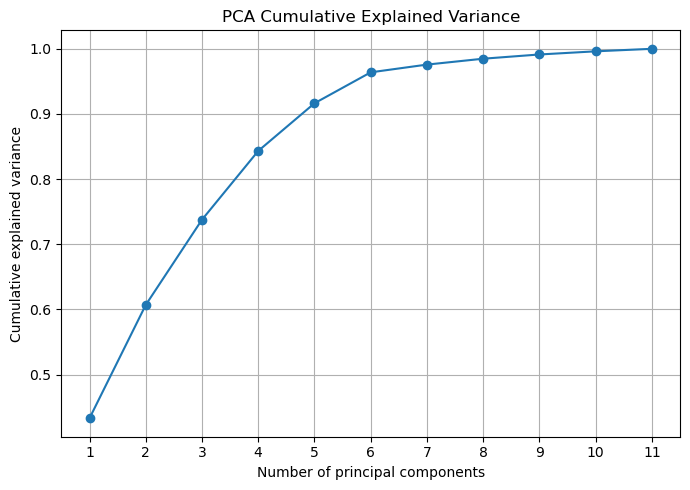

In [56]:
# Plot cumulative explained variance

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, len(pca_summary) + 1),
    pca_summary["cumulative_variance"],
    marker="o"
)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.xticks(range(1, len(pca_summary) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

### PCA Findings

PCA was used as an exploratory dimensionality-reduction tool for the numeric features.
The first principal component explained about 43% of the variance, and the first five 
components explained about 92% of the variance.

This suggests that the numeric features contain redundancy and can be summarized by 
fewer components. However, PCA components are less interpretable than the original 
health-related variables. Since this project focuses on diabetes risk screening and 
interpretability is important, PCA was not used as the main feature engineering approach
at this stage.

Instead, domain-driven features such as average blood pressure, BMI category, age group,
and high blood pressure indicators were preferred.

### Dimensionality Reduction: UMAP

UMAP was used as an exploratory nonlinear dimensionality-reduction method.
Unlike PCA, UMAP can capture nonlinear structure in the numeric features.
The goal is to visualize whether participants with and without diabetes show 
any separation in a low-dimensional space.

UMAP is used here only for exploration because its components are less interpretable
than domain-driven health features.

In [61]:
!pip install umap-learn

UMAP was attempted as an exploratory nonlinear dimensionality-reduction method,
but it was not used because of a package compatibility issue between `umap-learn` 
and `scikit-learn` in the local environment. PCA was used instead as the 
dimensionality-reduction method because it ran successfully and is easier to interpret.

### Time Features

Time-based feature engineering was not performed because this NHANES dataset 
is cross-sectional. Each row represents a different participant, not repeated
measurements of the same participant over time.

Therefore, lag features, rolling statistics, and seasonality components are not 
meaningful for this dataset. Feature engineering focused instead on domain-driven 
health features such as average blood pressure, BMI category, age group, and high 
blood pressure indicators.

In [62]:
# Summary of engineered features

engineered_features = [
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "bmi_category",
    "age_group",
    "high_bp_indicator",
    "waist_bmi_ratio"
]

df_fe[engineered_features].head()

,avg_systolic_bp,avg_diastolic_bp,bmi_category,age_group,high_bp_indicator,waist_bmi_ratio
0,99.000000,54.333333,obese,20-34,0.0,3.119048
1,NaN,NaN,NaN,20-34,NaN,NaN
2,107.000000,67.000000,overweight,35-49,0.0,4.053872
3,113.666667,67.333333,normal,35-49,0.0,3.963470
4,134.000000,70.000000,obese,65+,1.0,3.629139


In [63]:
print("Original dataset shape:", df.shape)
print("Feature-engineered dataset shape:", df_fe.shape)

Original dataset shape: (9232, 37)
Feature-engineered dataset shape: (9232, 43)


### Feature Engineering Summary

Six engineered features were created: average systolic blood pressure, average 
diastolic blood pressure, BMI category, age group, high blood pressure indicator,
and waist-to-BMI ratio.

These features were guided by EDA, domain knowledge, and redundancy checks. 
The average blood pressure features reduce redundancy among repeated blood pressure measurements.
BMI category and age group provide clinically interpretable grouped versions of
continuous variables. The high blood pressure indicator summarizes blood pressure risk,
while the waist-to-BMI ratio was explored but may not add strong separation between
diabetes groups.

PCA was also used as an exploratory dimensionality-reduction method, but domain-driven
features were preferred because they are easier to interpret for diabetes risk screening.

## 13. Iteration Between EDA and Feature Work

EDA, feature selection, and feature engineering were treated as an iterative process 
rather than one-time steps. The goal was not simply to create more features, but to 
use each step to improve understanding of the dataset and keep the modeling pipeline clean.

The workflow followed this cycle:

1. Explore data distributions, missingness, outliers, and relationships between variables.
2. Use EDA and domain knowledge to propose engineered features.
3. Test engineered features using summary statistics, group comparisons, correlations, and simple model-based diagnostics.
4. Keep features that have a defensible connection to diabetes risk and show useful signal.
5. Revise or discard features that appear redundant, unstable, or unhelpful.

In this project, EDA suggested that age, BMI, waist circumference, blood pressure, and physical activity variables may be important for diabetes risk screening. Based on these findings, 
several engineered features were created, including average systolic blood pressure, average diastolic blood pressure, BMI category, age group, and a high blood pressure indicator.

Not all engineered features are automatically useful. For example, the waist-to-BMI ratio was explored, but its mean and median values were very similar between diabetes and non-diabetes 
groups. This suggests that it may not add much additional signal beyond BMI and waist circumference themselves.

This iterative approach helps avoid keeping features “just in case.” Each feature should either improve interpretability, reduce redundancy, or provide useful predictive signal. Features that do not survive scrutiny should be revised or removed in later modeling.


In [64]:
# Save feature-engineered dataset

processed_dir = Path.home() / "Documents" / "diabetes-risk-project" / "data" / "processed"

df_fe.to_csv(processed_dir / "feature_engineered_dataset.csv", index=False)

print("Saved feature_engineered_dataset.csv")

Saved feature_engineered_dataset.csv


In [66]:
# Create results folder and save feature selection decisions

results_dir = Path.home() / "Documents" / "diabetes-risk-project" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

feature_decisions = pd.DataFrame([
    {
        "feature": "SEQN",
        "decision": "drop",
        "reason": "Participant identifier; not predictive health information."
    },
    {
        "feature": "diabetes",
        "decision": "drop",
        "reason": "Target variable; must not be used as predictor."
    },
    {
        "feature": "doctor_diabetes",
        "decision": "drop",
        "reason": "Encodes diabetes diagnosis and may leak target information."
    },
    {
        "feature": "DIQ010",
        "decision": "drop",
        "reason": "Doctor diagnosis variable used to define diabetes target."
    },
    {
        "feature": "LBXGH",
        "decision": "drop",
        "reason": "HbA1c lab value used to define diabetes target."
    },
    {
        "feature": "LBXGLU",
        "decision": "drop",
        "reason": "Fasting glucose lab value used to define diabetes target."
    },
    {
        "feature": "PAD660, PAQ655, PAD675, PAQ670",
        "decision": "keep for now / evaluate later",
        "reason": "High missingness, but may reflect survey skip patterns and physical activity information."
    },
    {
        "feature": "BPXOSY1, BPXOSY2, BPXOSY3",
        "decision": "engineer",
        "reason": "Highly correlated repeated systolic BP measurements; average systolic BP created."
    },
    {
        "feature": "BPXODI1, BPXODI2, BPXODI3",
        "decision": "engineer",
        "reason": "Highly correlated repeated diastolic BP measurements; average diastolic BP created."
    },
    {
        "feature": "avg_systolic_bp",
        "decision": "engineered",
        "reason": "Average systolic blood pressure created to reduce redundancy."
    },
    {
        "feature": "avg_diastolic_bp",
        "decision": "engineered",
        "reason": "Average diastolic blood pressure created to reduce redundancy."
    },
    {
        "feature": "bmi_category",
        "decision": "engineered",
        "reason": "Clinically interpretable BMI grouping."
    },
    {
        "feature": "age_group",
        "decision": "engineered",
        "reason": "Clinically interpretable age grouping."
    },
    {
        "feature": "high_bp_indicator",
        "decision": "engineered",
        "reason": "Summarizes blood pressure risk using average systolic/diastolic BP."
    },
    {
        "feature": "waist_bmi_ratio",
        "decision": "engineered / evaluate later",
        "reason": "Explored as a ratio feature, but showed little separation between diabetes groups."
    }
])

feature_decisions.to_csv(results_dir / "feature_selection.csv", index=False)

print("Saved feature_selection.csv")

Saved feature_selection.csv


In [67]:
pd.read_csv(results_dir / "feature_selection.csv")

,feature,decision,reason
0,SEQN,drop,Participant identifier; not predictive health ...
1,diabetes,drop,Target variable; must not be used as predictor.
2,doctor_diabetes,drop,Encodes diabetes diagnosis and may leak target...
3,DIQ010,drop,Doctor diagnosis variable used to define diabe...
4,LBXGH,drop,HbA1c lab value used to define diabetes target.
5,LBXGLU,drop,Fasting glucose lab value used to define diabe...
6,"PAD660, PAQ655, PAD675, PAQ670",keep for now / evaluate later,"High missingness, but may reflect survey skip ..."
7,"BPXOSY1, BPXOSY2, BPXOSY3",engineer,Highly correlated repeated systolic BP measure...
8,"BPXODI1, BPXODI2, BPXODI3",engineer,Highly correlated repeated diastolic BP measur...
9,avg_systolic_bp,engineered,Average systolic blood pressure created to red...


In [68]:
# Check that output files exist

from pathlib import Path
import pandas as pd

project_dir = Path.home() / "Documents" / "diabetes-risk-project"

feature_engineered_path = project_dir / "data" / "processed" / "feature_engineered_dataset.csv"
feature_selection_path = project_dir / "results" / "feature_selection.csv"

print("Feature-engineered dataset exists:", feature_engineered_path.exists())
print("Feature selection file exists:", feature_selection_path.exists())

Feature-engineered dataset exists: True
Feature selection file exists: True


In [69]:
# Check saved file contents

df_fe_check = pd.read_csv(feature_engineered_path)
feature_selection_check = pd.read_csv(feature_selection_path)

print("Feature-engineered dataset shape:", df_fe_check.shape)
print("Feature selection table shape:", feature_selection_check.shape)

display(df_fe_check.head())
display(feature_selection_check.head())

Feature-engineered dataset shape: (9232, 43)
Feature selection table shape: (15, 3)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPXOSY1,BPXOSY2,...,DBD905,DBD910,doctor_diabetes,diabetes,avg_systolic_bp,avg_diastolic_bp,bmi_category,age_group,high_bp_indicator,waist_bmi_ratio
0,109266.0,29.0,2.0,6.0,5.0,5.00,37.8,117.9,99.0,99.0,...,5.397605e-79,5.000000e+00,0.0,0,99.000000,54.333333,obese,20-34,0.0,3.119048
1,109267.0,21.0,2.0,2.0,4.0,5.00,NaN,NaN,NaN,NaN,...,5.397605e-79,5.397605e-79,0.0,0,NaN,NaN,NaN,20-34,NaN,NaN
2,109271.0,49.0,1.0,3.0,2.0,NaN,29.7,120.4,102.0,108.0,...,5.397605e-79,5.397605e-79,0.0,0,107.000000,67.000000,overweight,35-49,0.0,4.053872
3,109273.0,36.0,1.0,3.0,4.0,0.83,21.9,86.8,116.0,110.0,...,5.397605e-79,7.000000e+00,0.0,0,113.666667,67.333333,normal,35-49,0.0,3.963470
4,109274.0,68.0,1.0,7.0,4.0,1.20,30.2,109.6,138.0,132.0,...,5.397605e-79,5.397605e-79,1.0,1,134.000000,70.000000,obese,65+,1.0,3.629139


,feature,decision,reason
0,SEQN,drop,Participant identifier; not predictive health ...
1,diabetes,drop,Target variable; must not be used as predictor.
2,doctor_diabetes,drop,Encodes diabetes diagnosis and may leak target...
3,DIQ010,drop,Doctor diagnosis variable used to define diabe...
4,LBXGH,drop,HbA1c lab value used to define diabetes target.
